# Config

In [6]:
import pandas as pd
import openpyxl
import re
import ftfy
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import ggplot, aes, geom_col, labs, theme_minimal,  coord_flip
from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, REPORTS_DIR
from plots import plot_satisfaction_bar, plot_target_correlations, analyze_ppe_usage, usage_summary
pd.set_option('future.no_silent_downcasting', True)

# Read data

In [7]:
file_path = RAW_DATA_DIR / "FCTAES_279691_TOTAL_20251006.xlsx"

datos_df = pd.read_excel(file_path, sheet_name="Datos")
print("Datos",datos_df.shape)

labels_df = pd.read_excel(file_path, sheet_name="Labels")
print("Labels",labels_df.shape)

variables_df = pd.read_excel(file_path, sheet_name="Variables")
print("Variables",variables_df.shape)

# codes_df = pd.read_excel(file_path, sheet_name="Codes")
# print("Codes",codes_df.shape)

Datos (1813, 514)
Labels (1813, 514)
Variables (515, 4)


# Data processing

In [18]:
# -------------------------------
# Filter rows: motorcycle / moped users
# -------------------------------

# Work on a copy of the original dataframe
motocycle_df = datos_df.copy()

# Filter labels and data to motorcycle/moped users (column index 22 == 1)
labels_df = labels_df[labels_df.iloc[:, 22] == 1]
motocycle_df = motocycle_df[motocycle_df.iloc[:, 22] == 1]

# Fix text encoding issues in labels
labels_df = labels_df.map(
    lambda x: ftfy.fix_text(str(x)) if isinstance(x, str) else x
)

print("After filtering motorcycle/moped users:", motocycle_df.shape)


# -------------------------------
# Select relevant columns
# -------------------------------

# General variables
general_columns = (
    [motocycle_df.columns[12]] +
    motocycle_df.columns[15:21].tolist() +
    [motocycle_df.columns[22]] +
    [motocycle_df.columns[26]]
)

# Part 2 variables
part2_columns = motocycle_df.columns[29:127].tolist()

# Part 7 variables
part7_columns = motocycle_df.columns[448:454].tolist()

print("General columns:", general_columns)
print("Part 2 columns:", part2_columns)
print("Part 7 columns:", part7_columns)

# Keep only the selected columns
motocycle_df = motocycle_df[general_columns + part2_columns + part7_columns]

print("After selecting relevant columns:", motocycle_df.shape)


After filtering motorcycle/moped users: (905, 514)
General columns: ['SURVEY_COUNTRY', 'EDAD', 'EDADR', 'CITY_ES', 'CITY_IT', 'CITY_GB', 'CITY_DK', 'P2#1', 'TRANSPORT_1']
Part 2 columns: ['P3#1', 'P3#2', 'P3#3', 'P3#4', 'P4', 'P5', 'P6#1', 'P6#2', 'P6#96', 'P7_1', 'P7_2', 'P7_3', 'P7_4', 'P7_5', 'P7_6', 'P8#1', 'P8#2', 'P8#3', 'P8#97', 'P9#1', 'P9#2', 'P9#3', 'P9#4', 'P9#5', 'P9#6', 'P9#7', 'P9#8', 'P9#9', 'P9#10', 'P9#11', 'P9#12', 'P9#96', 'P9#96#value', 'P10_1', 'P10_2', 'P10_3', 'P10_4', 'P11_1', 'P11_2', 'P11_3', 'P11_4', 'P12_1', 'P12_2', 'P12_3', 'P12_4', 'P13', 'P14#1', 'P14#2', 'P14#3', 'P14#4', 'P14#5', 'P14#6', 'P14#7', 'P14#8', 'P14#9', 'P14#10', 'P14#11', 'P14#96', 'P14#96#value', 'P15_1', 'P15_2', 'P15_3', 'P15_4', 'P15_5', 'P15_6', 'P15_7', 'P15_8', 'P15_9', 'P15_10', 'P16', 'P17', 'P18#1', 'P18#2', 'P18#3', 'P18#4', 'P18#5', 'P18#6', 'P18#7', 'P18#8', 'P18#9', 'P18#10', 'P18#96', 'P18#96#value', 'P19_1', 'P19_2', 'P19_3', 'P19_4', 'P19_5', 'P19_6', 'P19_7', 'P19_8', 'P1

In [19]:

survey_attr_map = {
    # -------------------------------------------------
    # P9 — General safety gear (reasons, multi-select)
    # -------------------------------------------------
    "P9#1": "sg_reason_uncomfortable",
    "P9#2": "sg_reason_inconvenient",
    "P9#3": "sg_reason_dont_know_what_to_buy",
    "P9#4": "sg_reason_used_to_no_gear",
    "P9#5": "sg_reason_looks_bad",
    "P9#6": "sg_reason_experienced",
    "P9#7": "sg_reason_short_distance",
    "P9#8": "sg_reason_city_riding",
    "P9#9": "sg_reason_ride_infrequently",
    "P9#10": "sg_reason_not_protective",
    "P9#11": "sg_reason_others_dont_wear",
    "P9#12": "sg_reason_too_expensive",

    # -------------------------------------------------
    # P14 — Jacket with protection (reasons, multi-select)
    # -------------------------------------------------
    "P14#1": "jkt_reason_uncomfortable",
    "P14#2": "jkt_reason_inconvenient",
    "P14#3": "jkt_reason_too_hot",
    "P14#4": "jkt_reason_forget",
    "P14#5": "jkt_reason_looks_bad",
    "P14#6": "jkt_reason_not_protective",
    "P14#7": "jkt_reason_short_distance",
    "P14#8": "jkt_reason_city_riding",
    "P14#9": "jkt_reason_experienced",
    "P14#10": "jkt_reason_only_poor_visibility",
    "P14#11": "jkt_reason_others_dont_wear",

    # -------------------------------------------------
    # P15 — Jacket with protection (attitudes, Likert)
    # -------------------------------------------------
    "P15_1": "jkt_att_carrying_convenient",
    "P15_2": "jkt_att_wearing_pleasant",
    "P15_3": "jkt_att_reduces_injury_risk",
    "P15_4": "jkt_att_not_needed_short_trips",
    "P15_5": "jkt_att_only_needed_highways",
    "P15_6": "jkt_att_only_for_inexperienced",
    "P15_7": "jkt_att_others_wear",
    "P15_8": "jkt_att_friends_approve",
    "P15_9": "jkt_att_family_approve",
    "P15_10": "jkt_att_not_enforced_by_police",

    # -------------------------------------------------
    # P18 — Leg protection (reasons, multi-select)
    # -------------------------------------------------
    "P18#1": "leg_reason_uncomfortable",
    "P18#2": "leg_reason_inconvenient",
    "P18#3": "leg_reason_too_hot",
    "P18#4": "leg_reason_forget",
    "P18#5": "leg_reason_looks_bad",
    "P18#6": "leg_reason_not_protective",
    "P18#7": "leg_reason_short_distance",
    "P18#8": "leg_reason_city_riding",
    "P18#9": "leg_reason_experienced",
    "P18#10": "leg_reason_others_dont_wear",

    # -------------------------------------------------
    # P19 — Leg protection (attitudes, Likert)
    # -------------------------------------------------
    "P19_1": "leg_att_carrying_convenient",
    "P19_2": "leg_att_wearing_pleasant",
    "P19_3": "leg_att_reduces_injury_risk",
    "P19_4": "leg_att_not_needed_short_trips",
    "P19_5": "leg_att_only_needed_highways",
    "P19_6": "leg_att_only_for_inexperienced",
    "P19_7": "leg_att_others_wear",
    "P19_8": "leg_att_friends_approve",
    "P19_9": "leg_att_family_approve",
    "P19_10": "leg_att_not_enforced_by_police",
}

motocycle_df.rename(columns=survey_attr_map, inplace=True)


In [ ]:

# 1. Map for the Likert scale
likert_map = {
    1: "1 - Disagree",
    2: "2",
    3: "3",
    4: "4",
    5: "5 - Agree"
}
likert_order = ["1 - Disagree", "2", "3", "4", "5 - Agree"]

# COM-B Variables 

## CAPABILITY

### Reasons

In [39]:
# --- 1. Map & Melt General Barriers ---
reason_cols = ['sg_reason_uncomfortable', 'sg_reason_inconvenient', 'sg_reason_dont_know_what_to_buy']
reason_labels = {'sg_reason_uncomfortable': 'Uncomfortable', 'sg_reason_inconvenient': 'Inconvenient', 'sg_reason_dont_know_what_to_buy': "Don't know what to buy"}

reasons_long = (
    motocycle_df.melt(value_vars=reason_cols, var_name='Reason', value_name='Selected')
    .query('Selected == 1.0').assign(Reason=lambda d: d['Reason'].map(reason_labels))
)

# --- 2. Map & Melt PPE-Specific Barriers ---
barrier_map = {
    'jkt_reason_uncomfortable': ('Jacket', 'Uncomfortable'), 'jkt_reason_inconvenient': ('Jacket', 'Inconvenient'), 'jkt_reason_too_hot': ('Jacket', 'Too Hot'),
    'leg_reason_uncomfortable': ('Leg Protection', 'Uncomfortable'), 'leg_reason_inconvenient': ('Leg Protection', 'Inconvenient'), 'leg_reason_too_hot': ('Leg Protection', 'Too Hot')
}

barriers_long = (
    motocycle_df.melt(value_vars=barrier_map.keys(), var_name='col', value_name='selected')
    .query('selected == 1.0')
    .assign(
        Equipment=lambda d: d['col'].apply(lambda x: barrier_map[x][0]),
        Reason=lambda d: d['col'].apply(lambda x: barrier_map[x][1])
    )
)

# --- 3. Synchronize Categorical Order ---
# Combine all to find global frequency, then apply to all subsets
all_mentions = pd.concat([reasons_long[['Reason']], barriers_long[['Reason']]])
master_order = all_mentions['Reason'].value_counts().index.tolist()

reasons_long['Reason'] = pd.Categorical(reasons_long['Reason'], categories=master_order, ordered=True)
barriers_long['Reason'] = pd.Categorical(barriers_long['Reason'], categories=master_order, ordered=True)

# Separate PPE subsets for individual plotting if needed
jacket_reasons = barriers_long[barriers_long['Equipment'] == 'Jacket'].copy()
leg_reasons = barriers_long[barriers_long['Equipment'] == 'Leg Protection'].copy()


# --- Plot: PPE Side-by-Side (Jacket & Leg Protection) ---
plot_ppe = (
    ggplot(barriers_long, aes(x="Reason", fill="Equipment"))
    + geom_bar(show_legend=False, width=0.7)
    + facet_wrap('~Equipment', ncol=2, scales='free') 
    + coord_flip()
    + scale_fill_manual(values={"Jacket": "#E67E22", "Leg Protection": "#D35400"})
    + labs(title="Friction Points: Why gear isn't used every time", x=None, y="Mentions")
    + theme_minimal()
    + theme(figure_size=(12, 5), plot_title=element_text(hjust=0.5), strip_text=element_text(size=12, fontweight='bold'))
)

# --- Plot: General Barriers ---
plot_general = (
    ggplot(reasons_long, aes(x="Reason"))
    + geom_bar(fill="#e74c3c", width=0.7)
    + coord_flip()
    + labs(title="General Barriers to Using Safety Gear", x="Barriers", y="Mentions")
    + theme_minimal()
    + theme(figure_size=(8, 4), plot_title=element_text(hjust=0.5))
)

plot_ppe.save(FIGURES_DIR / "ppe_barriers.png", dpi=300)
plot_general.save(FIGURES_DIR / "general_barriers.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 12 x 5 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\ppe_barriers.png
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 4 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\general_barriers.png


### Evaluation

In [ ]:

# 3. Melt and Transform
att_long = (
    motocycle_df.melt(value_vars=att_cols.keys(), var_name='col', value_name='Score')
    .dropna(subset=['Score'])
)

# Apply mapping and category ordering
att_long['Equipment'] = att_long['col'].apply(lambda x: att_cols[x][0])
att_long['Statement'] = att_long['col'].apply(lambda x: att_cols[x][1])
att_long['Response'] = pd.Categorical(att_long['Score'].map(likert_map), 
                                      categories=likert_order, 
                                      ordered=True)
plot_attitudes = (
    ggplot(att_long, aes(x='Equipment', fill='Response'))
    + geom_bar(position="fill")
    + facet_wrap('~Statement', ncol=1) # Stack the two different questions
    + coord_flip()
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    # Use a diverging color palette (Red to Green)
    + scale_fill_brewer(type="div", palette="RdYlGn")
    + labs(
        title="Physical Capability & Attitudes toward PPE",
        subtitle="Scale from 1 (Disagree) to 5 (Agree)",
        x=None,
        y="Percentage of Respondents",
        fill="Agreement"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        legend_position="bottom",
        strip_text=element_text(size=11, fontweight='bold'),
    )
)

plot_attitudes.save(FIGURES_DIR / "attitudes_physical_capability.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\attitudes_physical_capability.png


## OPPORTUNITY

### Reasons

In [46]:
# --- 1. General Social & Financial (2 Columns) ---
gen_social_cols = ['sg_reason_others_dont_wear', 'sg_reason_too_expensive']
gen_social_labels = {
    'sg_reason_others_dont_wear': "Others don't wear it", 
    'sg_reason_too_expensive': "Too expensive"
}

# Melt and filter
gen_social_long = (
    motocycle_df.melt(value_vars=gen_social_cols, var_name='Reason', value_name='Selected')
    .query('Selected == 1.0')
)
gen_social_long['Reason'] = gen_social_long['Reason'].map(gen_social_labels)

# --- 2. PPE Social Barriers (2 Columns) ---
ppe_social_map = {
    'jkt_reason_others_dont_wear': ('Jacket', "Others don't wear it"),
    'leg_reason_others_dont_wear': ('Leg Protection', "Others don't wear it")
}

ppe_social_long = (
    motocycle_df.melt(value_vars=ppe_social_map.keys(), var_name='col', value_name='selected')
    .query('selected == 1.0')
)
ppe_social_long['Equipment'] = ppe_social_long['col'].apply(lambda x: ppe_social_map[x][0])
ppe_social_long['Reason'] = ppe_social_long['col'].apply(lambda x: ppe_social_map[x][1])

# --- 3. Synchronize Ordering ---
# We combine both lists to ensure the order is identical across General and PPE plots
all_mentions = pd.concat([gen_social_long[['Reason']], ppe_social_long[['Reason']]])
social_master_order = all_mentions['Reason'].value_counts().index.tolist()

gen_social_long['Reason'] = pd.Categorical(gen_social_long['Reason'], categories=social_master_order, ordered=True)
ppe_social_long['Reason'] = pd.Categorical(ppe_social_long['Reason'], categories=social_master_order, ordered=True)

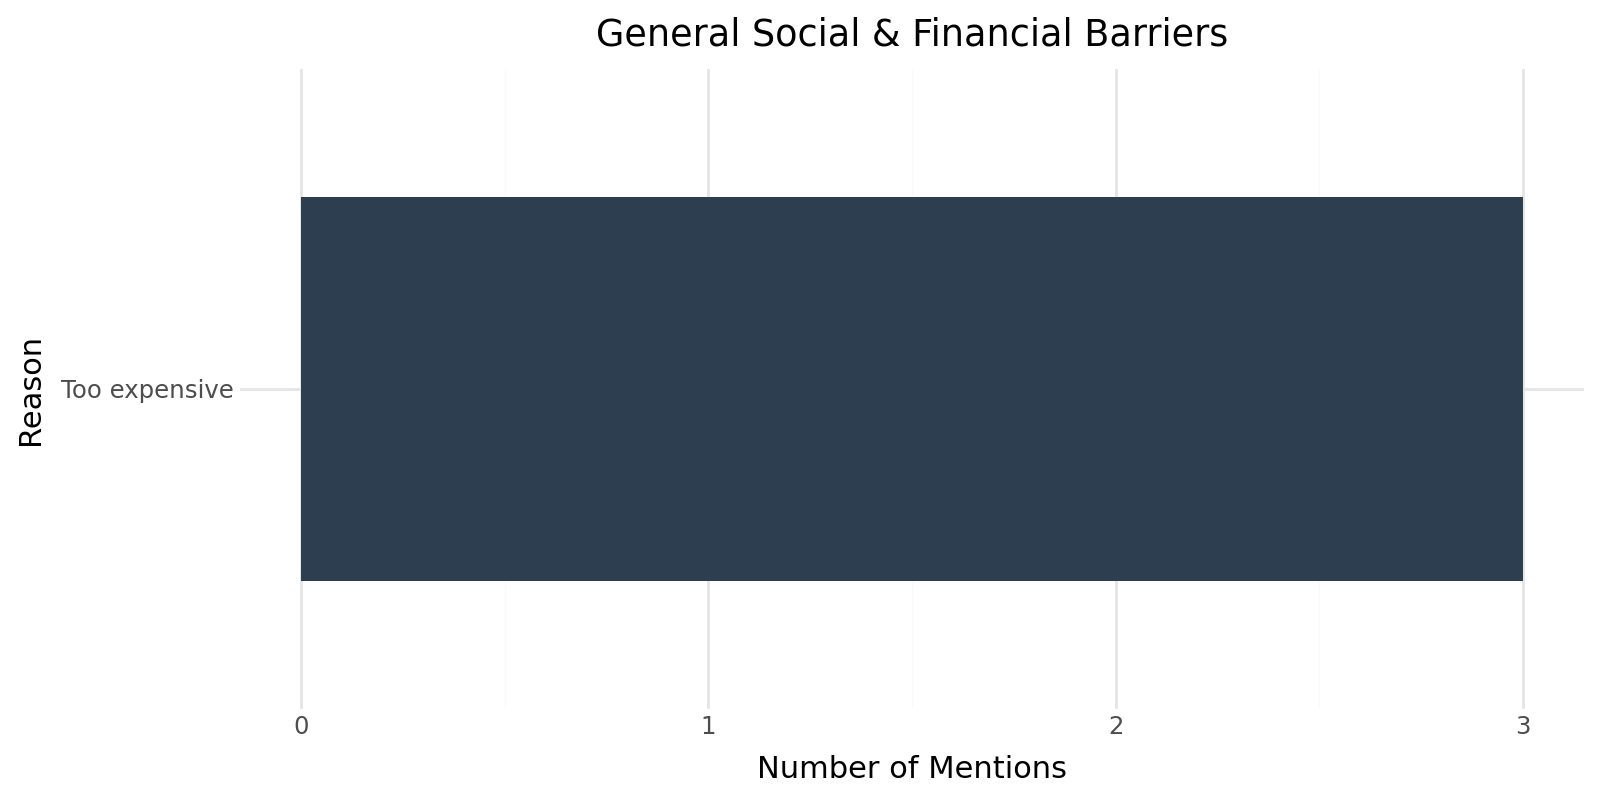

In [48]:
# --- Plot: General Barriers (Should now show 2 bars if data exists) ---
plot_gen_social = (
    ggplot(gen_social_long, aes(x="Reason"))
    + geom_bar(fill="#2c3e50", width=0.6)
    + coord_flip()
    + labs(
        title="General Social & Financial Barriers",
        x="Reason",
        y="Number of Mentions"
    )
    + theme_minimal()
    + theme(figure_size=(8, 4), plot_title=element_text(hjust=0.5))
)

# --- Plot: PPE Comparison ---
plot_ppe_social = (
    ggplot(ppe_social_long, aes(x="Reason", fill="Equipment"))
    + geom_bar(show_legend=False, width=0.6)
    + facet_wrap('~Equipment', ncol=2) 
    + coord_flip()
    + scale_fill_manual(values={"Jacket": "#16a085", "Leg Protection": "#1abc9c"})
    + labs(
        title="Social Influence: 'Others don't wear it'",
        x=None,
        y="Number of Mentions"
    )
    + theme_minimal()
    + theme(
        figure_size=(12, 4), 
        plot_title=element_text(hjust=0.5),
        strip_text=element_text(size=12, fontweight='bold')
    )
)

plot_gen_social

### Evaluation

In [34]:
# 2. Define the columns and their metadata
att_cols = {
    "jkt_att_others_wear": ("Jacket", "Others Wear"),
    "jkt_att_friends_approve": ("Jacket", "Friends Approve"),
    "jkt_att_family_approve": ("Jacket", "Family Approve"),
    "jkt_att_not_enforced_by_police": ("Jacket", "Not Enforced by Police"),

    "leg_att_others_wear": ("Leg Protection", "Others Wear"),
    "leg_att_friends_approve": ("Leg Protection", "Friends Approve"),
    "leg_att_family_approve": ("Leg Protection", "Family Approve"),
    "leg_att_not_enforced_by_police": ("Leg Protection", "Not Enforced by Police"),
}

# 3. Melt and Transform
att_long = (
    motocycle_df.melt(value_vars=att_cols.keys(), var_name='col', value_name='Score')
    .dropna(subset=['Score'])
)

# Apply mapping and category ordering
att_long['Equipment'] = att_long['col'].apply(lambda x: att_cols[x][0])
att_long['Statement'] = att_long['col'].apply(lambda x: att_cols[x][1])
att_long['Response'] = pd.Categorical(
    att_long['Score'].map(likert_map),
    categories=likert_order,
    ordered=True
)

# 4. Plot
plot_attitudes = (
    ggplot(att_long, aes(x='Equipment', fill='Response'))
    + geom_bar(position="fill")
    + facet_wrap('~Statement', ncol=1)
    + coord_flip()
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn")
    + labs(
        title="Opportunity: Social Influence & Attitudes toward PPE",
        subtitle="Scale from 1 (Disagree) to 5 (Agree)",
        x=None,
        y="Percentage of Respondents",
        fill="Agreement"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        legend_position="bottom",
        strip_text=element_text(size=11, fontweight='bold'),
    )
)

# Save figure
plot_attitudes.save(FIGURES_DIR / "attitudes_opportunity.png", dpi=300)


c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\attitudes_opportunity.png


## MOTIVATION

### Reasons

In [49]:
# --- 1. Map & Melt General Behavioral Barriers ---
gen_beh_cols = [
    'sg_reason_used_to_no_gear', 'sg_reason_looks_bad', 'sg_reason_experienced',
    'sg_reason_short_distance', 'sg_reason_city_riding', 
    'sg_reason_ride_infrequently', 'sg_reason_not_protective'
]
gen_beh_labels = {
    'sg_reason_used_to_no_gear': 'Used to no gear', 'sg_reason_looks_bad': 'Looks bad',
    'sg_reason_experienced': 'Experienced rider', 'sg_reason_short_distance': 'Short distance',
    'sg_reason_city_riding': 'City riding only', 'sg_reason_ride_infrequently': 'Infrequent rider',
    'sg_reason_not_protective': 'Not protective enough'
}

gen_beh_long = (
    motocycle_df.melt(value_vars=gen_beh_cols, var_name='Reason', value_name='Selected')
    .query('Selected == 1.0').assign(Reason=lambda d: d['Reason'].map(gen_beh_labels))
)

# --- 2. Map & Melt PPE-Specific Behavioral Barriers ---
ppe_beh_map = {
    'jkt_reason_forget': ('Jacket', 'Forgot it'), 'jkt_reason_looks_bad': ('Jacket', 'Looks bad'),
    'jkt_reason_not_protective': ('Jacket', 'Not protective'), 'jkt_reason_short_distance': ('Jacket', 'Short distance'),
    'jkt_reason_city_riding': ('Jacket', 'City riding'), 'jkt_reason_experienced': ('Jacket', 'Experienced'),
    'jkt_reason_only_poor_visibility': ('Jacket', 'Only for poor visibility'),
    'leg_reason_forget': ('Leg Protection', 'Forgot it'), 'leg_reason_looks_bad': ('Leg Protection', 'Looks bad'),
    'leg_reason_not_protective': ('Leg Protection', 'Not protective'), 'leg_reason_short_distance': ('Leg Protection', 'Short distance'),
    'leg_reason_city_riding': ('Leg Protection', 'City riding'), 'leg_reason_experienced': ('Leg Protection', 'Experienced')
}

ppe_beh_long = (
    motocycle_df.melt(value_vars=ppe_beh_map.keys(), var_name='col', value_name='selected')
    .query('selected == 1.0')
    .assign(
        Equipment=lambda d: d['col'].apply(lambda x: ppe_beh_map[x][0]),
        Reason=lambda d: d['col'].apply(lambda x: ppe_beh_map[x][1])
    )
)

# --- 3. Synchronize Categorical Order ---
all_beh_mentions = pd.concat([gen_beh_long[['Reason']], ppe_beh_long[['Reason']]])
beh_master_order = all_beh_mentions['Reason'].value_counts().index.tolist()

gen_beh_long['Reason'] = pd.Categorical(gen_beh_long['Reason'], categories=beh_master_order, ordered=True)
ppe_beh_long['Reason'] = pd.Categorical(ppe_beh_long['Reason'], categories=beh_master_order, ordered=True)

In [51]:
# --- Plot: General Behavioral Barriers ---
plot_gen_beh = (
    ggplot(gen_beh_long, aes(x="Reason"))
    + geom_bar(fill="#34495e", width=0.7)
    + coord_flip()
    + labs(title="General Behavioral Barriers", x="Reason", y="Mentions")
    + theme_minimal()
    + theme(figure_size=(8, 5), plot_title=element_text(hjust=0.5))
)

# --- Plot: PPE Behavioral Comparison ---
plot_ppe_beh = (
    ggplot(ppe_beh_long, aes(x="Reason", fill="Equipment"))
    + geom_bar(show_legend=False, width=0.7)
    + facet_wrap('~Equipment', ncol=2) 
    + coord_flip()
    + scale_fill_manual(values={"Jacket": "#2980b9", "Leg Protection": "#16a085"})
    + labs(title="Behavioral Friction: Jacket vs. Leg Protection", x=None, y="Mentions")
    + theme_minimal()
    + theme(
        figure_size=(14, 6), 
        plot_title=element_text(hjust=0.5),
        strip_text=element_text(size=12, fontweight='bold')
    )
)

plot_gen_beh.save(FIGURES_DIR / "behavioral_barriers.png", dpi=300)
plot_ppe_beh.save(FIGURES_DIR / "ppe_behavioral_barriers.png", dpi=300)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 5 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\behavioral_barriers.png
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\ppe_behavioral_barriers.png


### Evaluation


In [33]:
# 2. Columns and metadata for risk perception / necessity
att_cols = {
    "jkt_att_reduces_injury_risk": ("Jacket", "Reduces Injury Risk"),
    "jkt_att_not_needed_short_trips": ("Jacket", "Not Needed for Short Trips"),
    "jkt_att_only_needed_highways": ("Jacket", "Only Needed on Highways"),
    "jkt_att_only_for_inexperienced": ("Jacket", "Only for Inexperienced Riders"),

    "leg_att_reduces_injury_risk": ("Leg Protection", "Reduces Injury Risk"),
    "leg_att_not_needed_short_trips": ("Leg Protection", "Not Needed for Short Trips"),
    "leg_att_only_needed_highways": ("Leg Protection", "Only Needed on Highways"),
    "leg_att_only_for_inexperienced": ("Leg Protection", "Only for Inexperienced Riders"),
}

# 3. Melt and transform
att_long = (
    motocycle_df.melt(value_vars=att_cols.keys(), var_name='col', value_name='Score')
    .dropna(subset=['Score'])
)

att_long['Equipment'] = att_long['col'].apply(lambda x: att_cols[x][0])
att_long['Statement'] = att_long['col'].apply(lambda x: att_cols[x][1])
att_long['Response'] = pd.Categorical(
    att_long['Score'].map(likert_map),
    categories=likert_order,
    ordered=True
)

# 4. Plot
plot_attitudes = (
    ggplot(att_long, aes(x='Equipment', fill='Response'))
    + geom_bar(position="fill")
    + facet_wrap('~Statement', ncol=1)
    + coord_flip()
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn")
    + labs(
        title="Motivation: Perceived Necessity & Risk Reduction of PPE",
        subtitle="Scale from 1 (Disagree) to 5 (Agree)",
        x=None,
        y="Percentage of Respondents",
        fill="Agreement"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        legend_position="bottom",
        strip_text=element_text(size=11, fontweight='bold'),
    )
)

# Save figure
plot_attitudes.save(FIGURES_DIR / "attitudes_motivation.png", dpi=300)


c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 10 x 8 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\attitudes_motivation.png


# Save data

In [ ]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

